# Классификация Симпсонов

Импорт библиотек

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


Загрузка датасета

In [ ]:
TRAIN_DIR = '/home/l.bazdyrev/AI/ai_learn/simpsons/archive/simpsons_dataset'
TEST_DIR  = '/home/l.bazdyrev/AI/ai_learn/simpsons/archive/kaggle_simpson_testset/kaggle_simpson_testset'

MIN_SAMPLES = 50

class_names_all = sorted(os.listdir(TRAIN_DIR))
class_counts = {}
for cls in class_names_all:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_dir):
        n = len([f for f in os.listdir(cls_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
        class_counts[cls] = n

class_names = sorted([c for c, n in class_counts.items() if n >= MIN_SAMPLES])
num_classes = len(class_names)
class_to_idx = {c: i for i, c in enumerate(class_names)}

print(f'Всего папок: {len(class_counts)}')
print(f'Классов после фильтрации (>= {MIN_SAMPLES} изображений): {num_classes}')
print(f'Классы: {class_names}')

Всего папок: 43
Классов после фильтрации (>= 50 изображений): 31
Классы: ['abraham_grampa_simpson', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson', 'carl_carlson', 'charles_montgomery_burns', 'chief_wiggum', 'comic_book_guy', 'edna_krabappel', 'groundskeeper_willie', 'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lenny_leonard', 'lisa_simpson', 'maggie_simpson', 'marge_simpson', 'martin_prince', 'mayor_quimby', 'milhouse_van_houten', 'moe_szyslak', 'ned_flanders', 'nelson_muntz', 'patty_bouvier', 'principal_skinner', 'professor_john_frink', 'ralph_wiggum', 'selma_bouvier', 'sideshow_bob', 'snake_jailbird', 'waylon_smithers']


Распределение классов

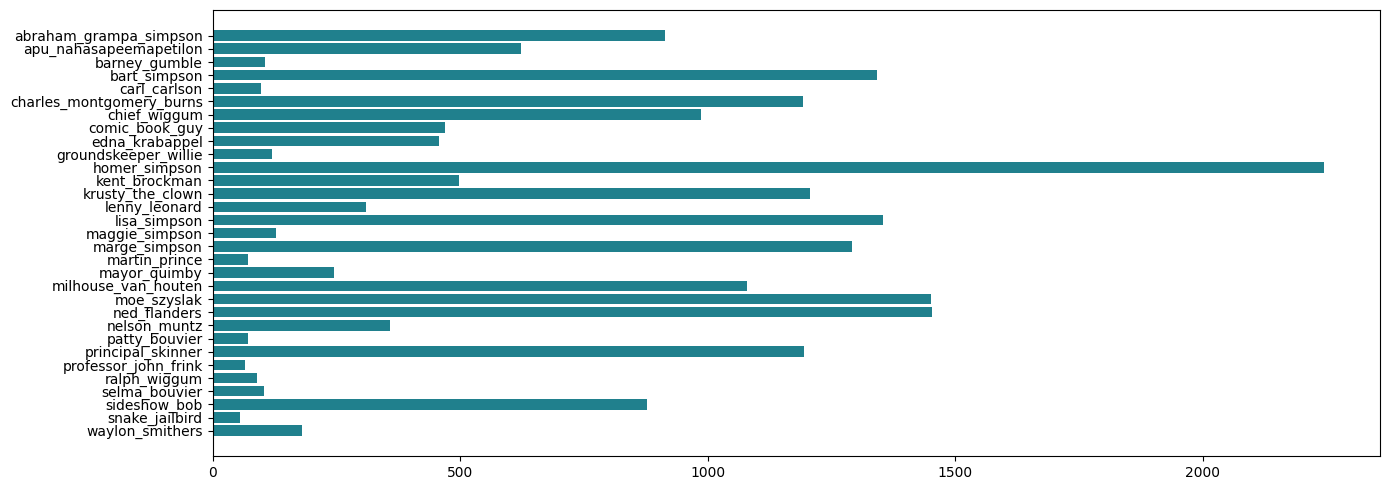

Всего изображений: 20637


In [ ]:
filtered_counts = {c: class_counts[c] for c in class_names}
plt.figure(figsize=(14, 5))
bars = plt.barh(list(filtered_counts.keys()), list(filtered_counts.values()), color='#20808D')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

total_images = sum(filtered_counts.values())
print(f'Всего изображений: {total_images}')

Предобработка данных

In [4]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.2),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [5]:
class SimpsonsDataset(Dataset):
    def __init__(self, root_dir, class_names, class_to_idx, transform=None):
        self.transform = transform
        self.samples = []
        for cls in class_names:
            cls_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    self.samples.append((os.path.join(cls_dir, fname), class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


class SimpsonsTestDataset(Dataset):
    def __init__(self, root_dir, class_names, class_to_idx, transform=None):
        self.transform = transform
        self.samples = []
        self.class_to_idx = class_to_idx
        self.class_names = class_names

        for fname in sorted(os.listdir(root_dir)):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                continue
            path = os.path.join(root_dir, fname)
            label = self._parse_label(fname)
            self.samples.append((path, label))

    def _parse_label(self, fname):
        name = fname.rsplit('.', 1)[0]
        parts = name.split('_')
        while parts and parts[-1].isdigit():
            parts.pop()
        candidate = '_'.join(parts)
        if candidate in self.class_to_idx:
            return self.class_to_idx[candidate]
        return -1

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

train / val

In [6]:
full_dataset = SimpsonsDataset(TRAIN_DIR, class_names, class_to_idx, transform=None)
print(f'Всего обучающих изображений: {len(full_dataset)}')

# 80 / 20
val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_subset, val_subset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f'Train: {len(train_subset)}, Val: {len(val_subset)}')

Всего обучающих изображений: 20637
Train: 16510, Val: 4127


In [7]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


train_ds = TransformSubset(train_subset, train_transform)
val_ds   = TransformSubset(val_subset, val_transform)

In [8]:
train_labels = [full_dataset.samples[i][1] for i in train_subset.indices]
label_counts = Counter(train_labels)
weights_per_class = {c: 1.0 / label_counts[c] for c in label_counts}
sample_weights = [weights_per_class[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Батчей в train: {len(train_loader)}, в val: {len(val_loader)}')

Батчей в train: 258, в val: 65


Примеры изображений из обучающей выборки

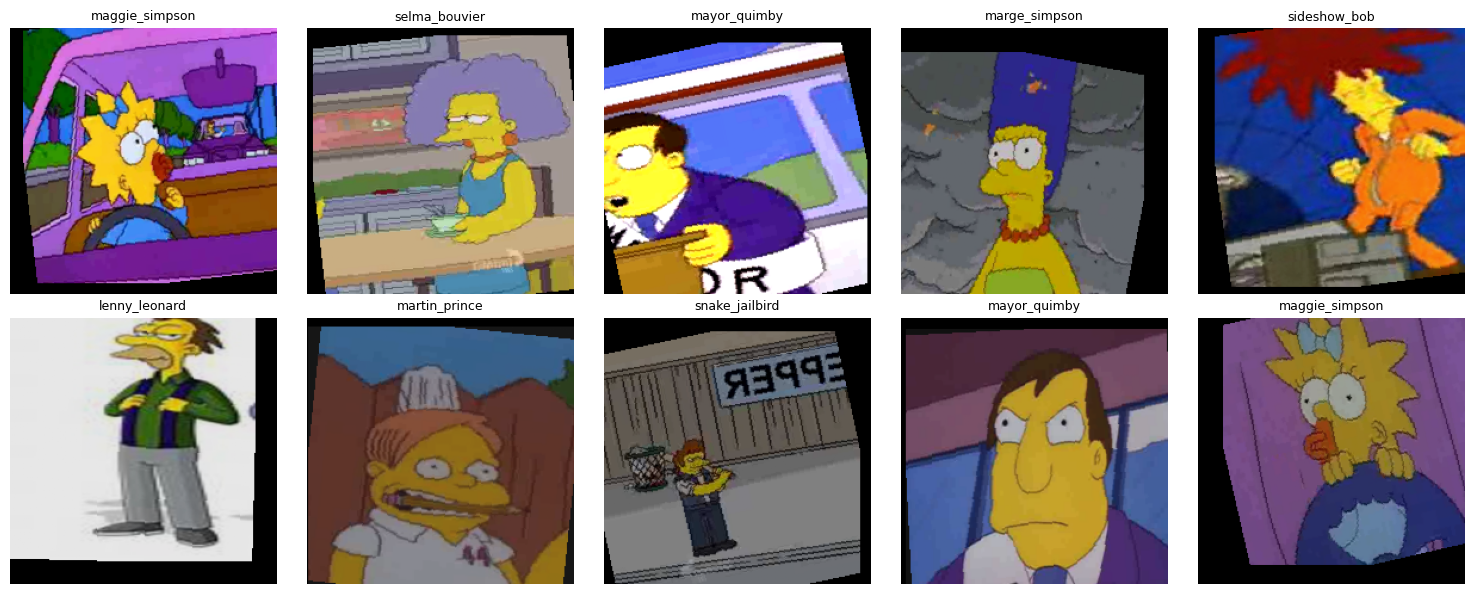

In [9]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[labels[i]], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

Модель

Используем ResNet18.  

In [10]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

ct = 0
for child in model.children():
    ct += 1
    if ct < 7:
        for param in child.parameters():
            param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Параметров всего: {total:,}, обучаемых: {trainable:,}')

Параметров всего: 11,192,415, обучаемых: 10,509,343


Обучение

Loss: CrossEntropyLoss  
Optimizer: SGD
Scheduler: ReduceLROnPlateau 
Эпохи: 15  
Early stopping: patience=5

In [11]:
NUM_EPOCHS = 15
LR = 0.01
PATIENCE = 5

all_labels = [s[1] for s in full_dataset.samples]
counts = Counter(all_labels)
class_weights = torch.tensor(
    [1.0 / counts[i] for i in range(num_classes)], dtype=torch.float).to(device)
class_weights = class_weights / class_weights.sum() * num_classes

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

Цикл обучения

In [12]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [train]', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [val]', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc  = correct / total

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:2d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} |'
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} |')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            break

print(f'\nЛучшая val accuracy: {best_val_acc:.4f}')

Epoch  1 | train_loss=0.7387 train_acc=0.5671 |val_loss=0.6910 val_acc=0.6770 |


Epoch  2 | train_loss=0.1776 train_acc=0.8466 |val_loss=0.4699 val_acc=0.8214 |


Epoch  3 | train_loss=0.1287 train_acc=0.8898 |val_loss=0.3427 val_acc=0.8781 |


Epoch  4 | train_loss=0.0903 train_acc=0.9132 |val_loss=0.3322 val_acc=0.8948 |


Epoch  5 | train_loss=0.0776 train_acc=0.9280 |val_loss=0.3185 val_acc=0.9142 |


...

Epoch 11 | train_loss=0.0367 train_acc=0.9585 |val_loss=0.3079 val_acc=0.9414 |


Epoch 12 | train_loss=0.0355 train_acc=0.9603 |val_loss=0.3147 val_acc=0.9428 |


Epoch 13 | train_loss=0.0355 train_acc=0.9625 |val_loss=0.3154 val_acc=0.9455 |


Epoch 14 | train_loss=0.0316 train_acc=0.9627 |val_loss=0.3027 val_acc=0.9445 |


Epoch 15 | train_loss=0.0323 train_acc=0.9626 |val_loss=0.2994 val_acc=0.9472 |

Лучшая val accuracy: 0.9472


Графики обучения

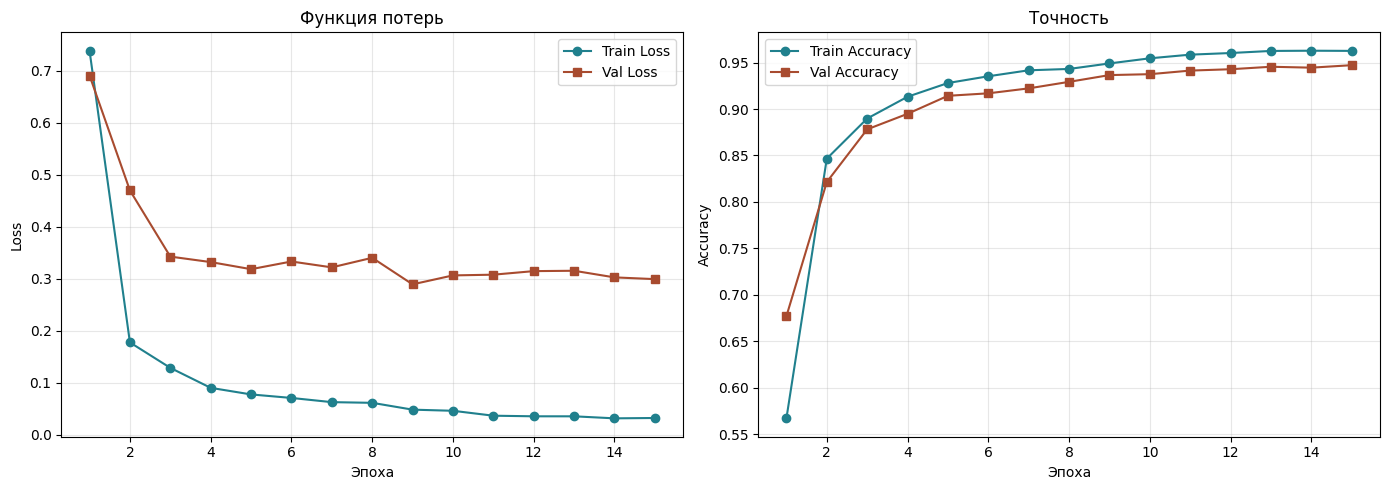

In [13]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#20808D')
ax1.plot(epochs_range, history['val_loss'], 's-', label='Val Loss', color='#A84B2F')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.set_title('Функция потерь')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, history['train_acc'], 'o-', label='Train Accuracy', color='#20808D')
ax2.plot(epochs_range, history['val_acc'], 's-', label='Val Accuracy', color='#A84B2F')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.set_title('Точность')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Тест

In [20]:
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

test_ds = SimpsonsTestDataset(TEST_DIR, class_names, class_to_idx, transform=val_transform)

known_indices = [i for i, (_, lbl) in enumerate(test_ds.samples) if lbl != -1]

from torch.utils.data import Subset
test_known = Subset(test_ds, known_indices)
test_loader = DataLoader(test_known, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [15]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

Testing: 100%|██████████| 16/16 [00:01<00:00, 12.10it/s]


Метрики

In [21]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-score:  {f1:.4f}')
print()

present_labels = sorted(set(all_labels.tolist()) | set(all_preds.tolist()))
present_names  = [class_names[i] for i in present_labels]

print(classification_report(
    all_labels, all_preds,
    labels=present_labels,
    target_names=present_names,
    zero_division=0
))

Accuracy:  0.9768
Precision: 0.9796
Recall:    0.9768
F1-score:  0.9777

                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.98      0.88      0.92        48
  apu_nahasapeemapetilon       1.00      1.00      1.00        50
            bart_simpson       1.00      0.96      0.98        50
charles_montgomery_burns       0.90      0.98      0.94        48
            chief_wiggum       1.00      1.00      1.00        50
          comic_book_guy       1.00      1.00      1.00        49
          edna_krabappel       1.00      0.98      0.99        50
           homer_simpson       0.94      0.96      0.95        50
           kent_brockman       0.94      1.00      0.97        50
        krusty_the_clown       0.94      1.00      0.97        50
           lenny_leonard       0.98      1.00      0.99        50
            lisa_simpson       1.00      0.96      0.98        50
          maggie_simpson       0.00      0.00      0.00         0
  

Матрица ошибок

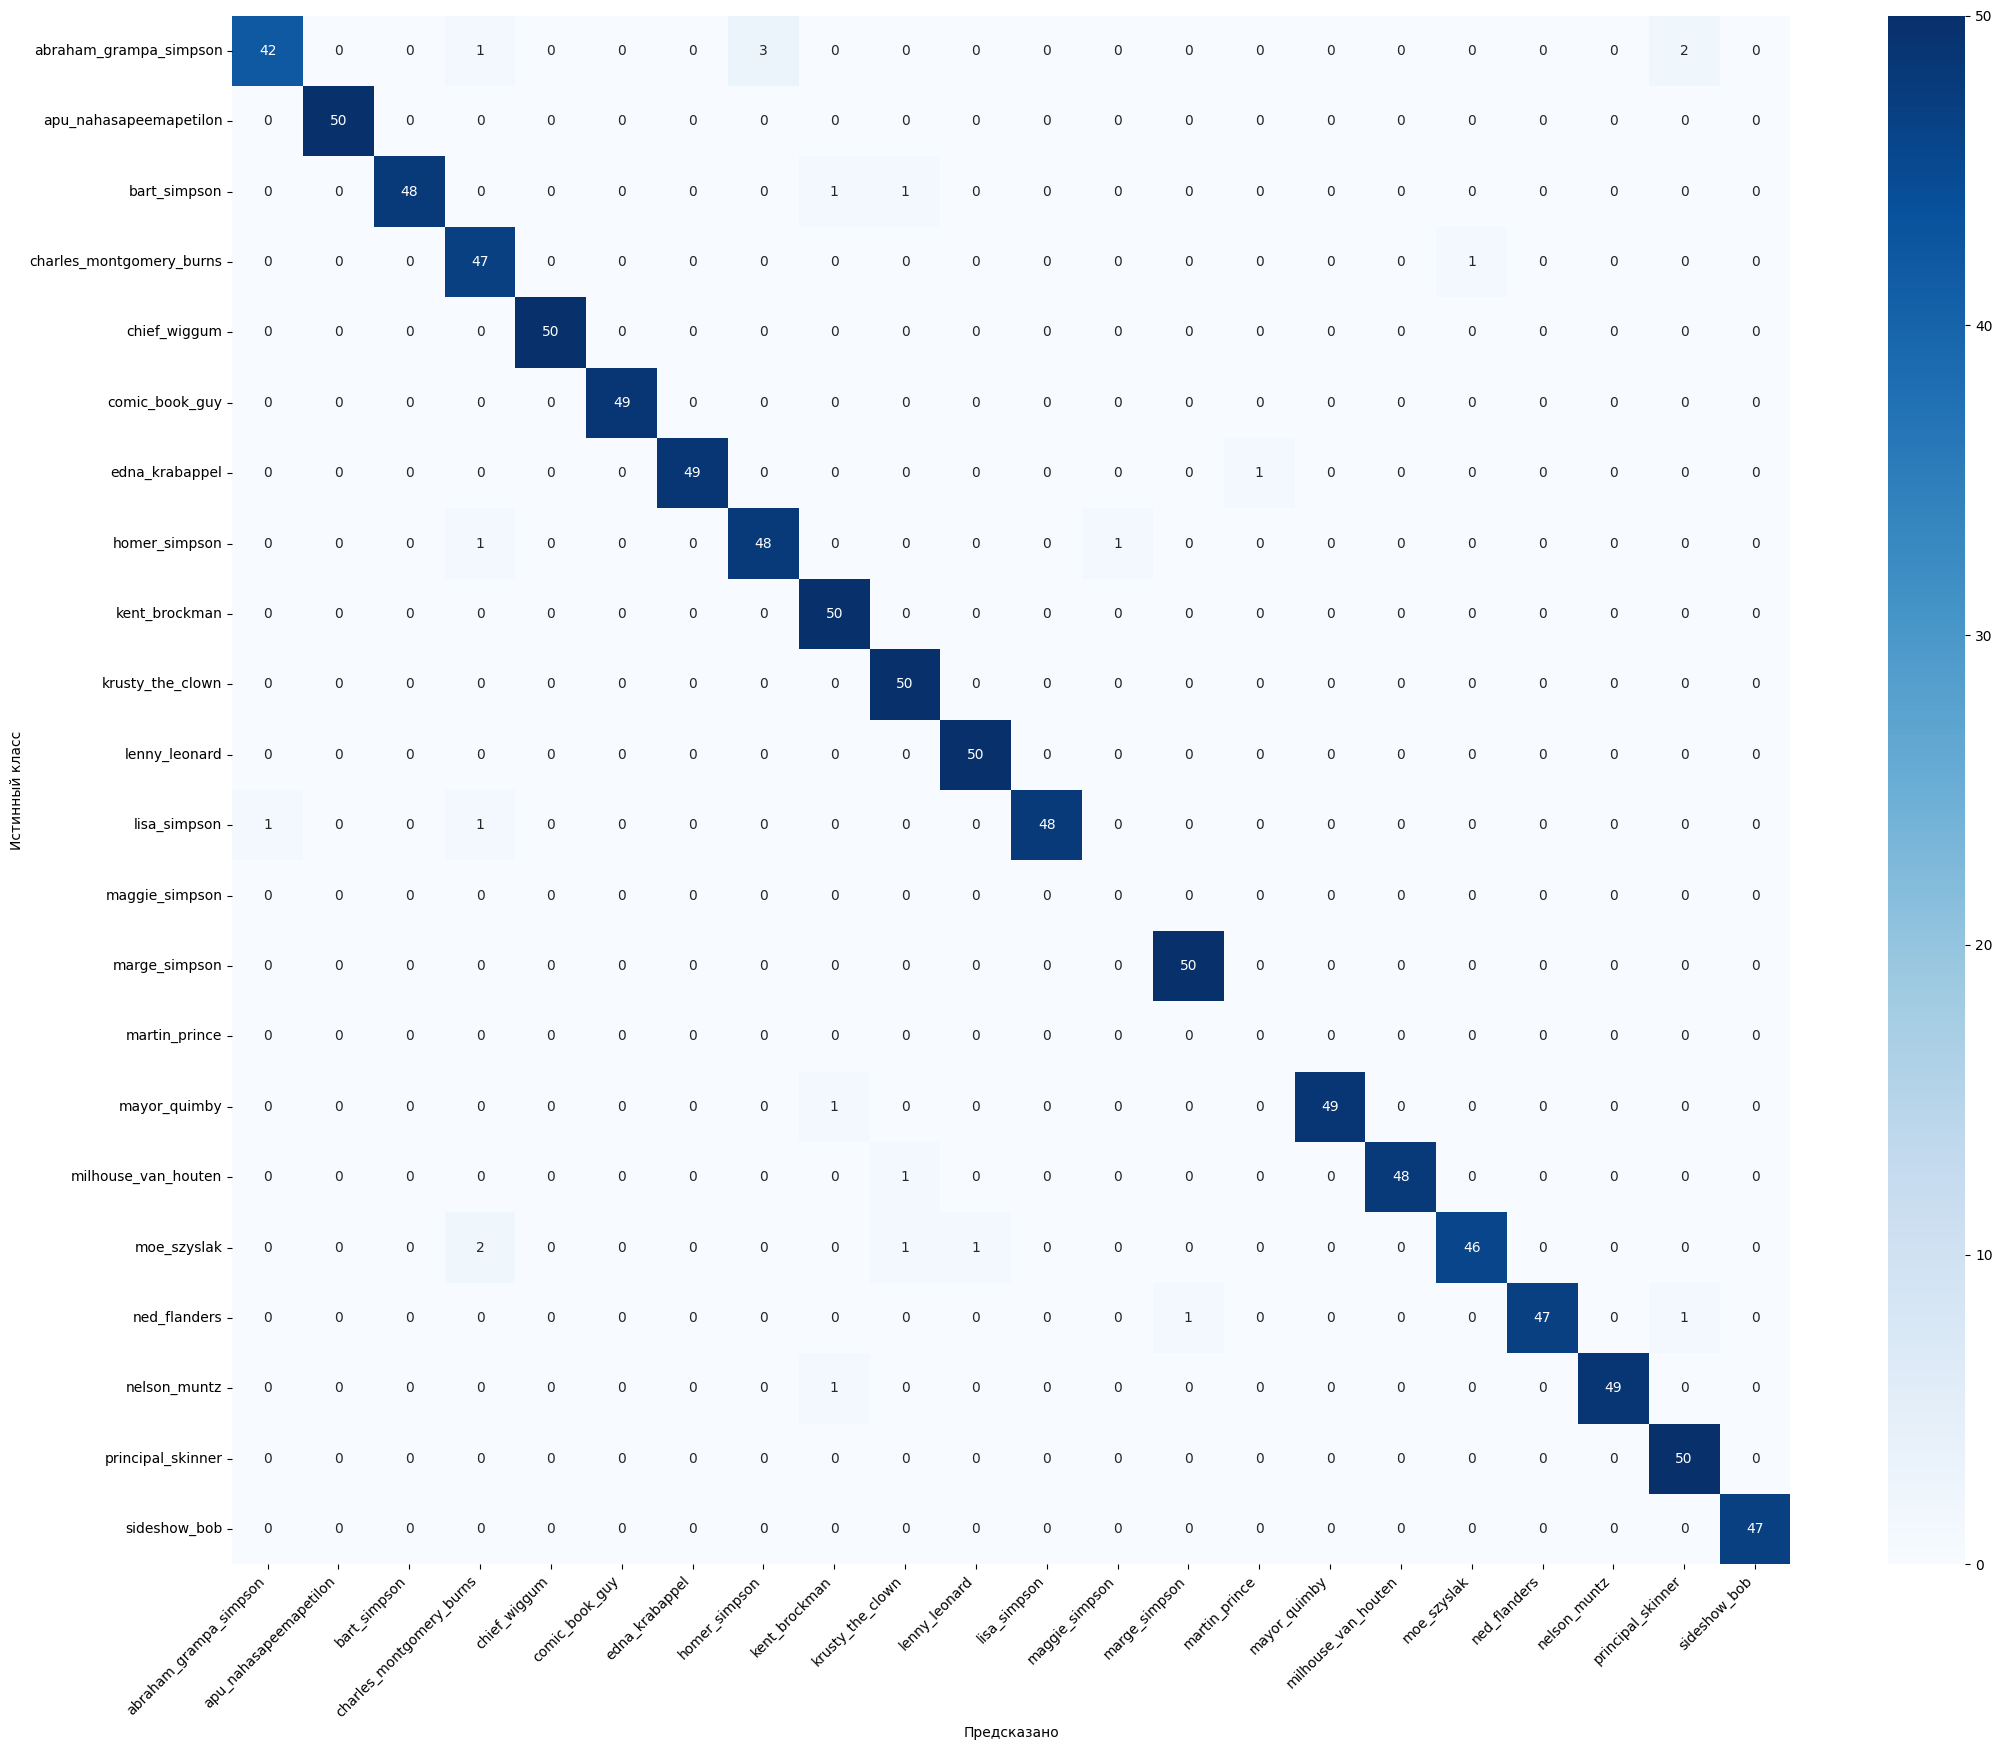

In [17]:
cm = confusion_matrix(all_labels, all_preds, labels=present_labels)

plt.figure(figsize=(max(12, len(present_names)), max(10, len(present_names) * 0.8)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names)
plt.xlabel('Предсказано')
plt.ylabel('Истинный класс')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
errors = {}
for t, p in zip(all_labels, all_preds):
    if t != p:
        key = (class_names[t], class_names[p])
        errors[key] = errors.get(key, 0) + 1

top_errors = sorted(errors.items(), key=lambda x: -x[1])[:15]
print('15 наиболее частых ошибок:')
print(f'{"Истинный":30s} → {"Предсказано":30s} | Кол-во')
print('-' * 75)
for (true_cls, pred_cls), count in top_errors:
    print(f'{true_cls:30s} → {pred_cls:30s} | {count}')

15 наиболее частых ошибок:
Истинный                       → Предсказано                    | Кол-во
---------------------------------------------------------------------------
abraham_grampa_simpson         → homer_simpson                  | 3
abraham_grampa_simpson         → principal_skinner              | 2
moe_szyslak                    → charles_montgomery_burns       | 2
abraham_grampa_simpson         → charles_montgomery_burns       | 1
bart_simpson                   → krusty_the_clown               | 1
bart_simpson                   → kent_brockman                  | 1
charles_montgomery_burns       → moe_szyslak                    | 1
edna_krabappel                 → martin_prince                  | 1
homer_simpson                  → charles_montgomery_burns       | 1
homer_simpson                  → maggie_simpson                 | 1
lisa_simpson                   → charles_montgomery_burns       | 1
lisa_simpson                   → abraham_grampa_simpson         | 1
mayor_qu

Оценка на валидационной выборке

In [19]:
val_preds = []
val_true  = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Val eval'):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        val_preds.extend(preds)
        val_true.extend(labels.numpy())

val_acc = accuracy_score(val_true, val_preds)
print(f'Validation Accuracy: {val_acc:.4f}')

Val eval: 100%|██████████| 65/65 [00:07<00:00,  9.21it/s]

Validation Accuracy: 0.9472
